In [1]:
# Machine Learning Model for Anemia Analysis

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("Anemia_Data_With_Risk_Score.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (706, 18)


,District,State,Women_Literacy,Women_Schooling,Teenage_Pregnancy,IFA_Consumption,Institutional_Births,Low_BMI,Improved_Sanitation,Clean_Cooking_Fuel,Health_Insurance,Women_Anemia,Children_Anemia,NonPregnant_Anemia,Pregnant_Anemia,Teen_Women_Anemia,Risk Score,Risk Category
0,Nicobars,Andaman & Nicobar Islands,87.5,53.5,1.8,72.6,97.8,8.2,83.5,56.9,2.7,38.3,37.7,38.4,51.9,48.0,23.505,Low
1,North & Middle Andaman,Andaman & Nicobar Islands,84.0,41.0,3.8,83.7,97.7,8.6,86.4,61.3,2.1,62.1,30.4,62.5,51.9,47.8,30.340,Moderate
2,South Andaman,Andaman & Nicobar Islands,86.7,57.5,2.8,81.0,99.5,10.0,89.3,91.9,1.2,57.7,43.4,57.6,51.9,43.2,28.645,Moderate
3,Srikakulam,Andhra Pradesh,64.3,42.5,5.5,67.5,97.9,13.8,71.6,74.7,75.6,62.6,59.6,62.8,51.9,59.2,39.160,Moderate
4,Vizianagaram,Andhra Pradesh,58.3,37.6,12.7,59.6,99.0,16.9,61.7,60.3,76.7,64.0,66.7,64.6,51.9,73.9,43.840,Moderate


In [3]:
# Check columns and data types

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['District', 'State', 'Women_Literacy', 'Women_Schooling', 'Teenage_Pregnancy', 'IFA_Consumption', 'Institutional_Births', 'Low_BMI', 'Improved_Sanitation', 'Clean_Cooking_Fuel', 'Health_Insurance', 'Women_Anemia', 'Children_Anemia', 'NonPregnant_Anemia', 'Pregnant_Anemia', 'Teen_Women_Anemia', 'Risk Score', 'Risk Category']

Data types:
District                 object
State                    object
Women_Literacy          float64
Women_Schooling         float64
Teenage_Pregnancy       float64
IFA_Consumption         float64
Institutional_Births    float64
Low_BMI                 float64
Improved_Sanitation     float64
Clean_Cooking_Fuel      float64
Health_Insurance        float64
Women_Anemia            float64
Children_Anemia         float64
NonPregnant_Anemia      float64
Pregnant_Anemia         float64
Teen_Women_Anemia       float64
Risk Score              float64
Risk Category            object
dtype: object


In [4]:
# Columns used for machine learning
features = [
    "Women_Literacy",
    "Women_Schooling",
    "Teenage_Pregnancy",
    "IFA_Consumption",
    "Institutional_Births",
    "Low_BMI",
    "Improved_Sanitation",
    "Clean_Cooking_Fuel",
    "Health_Insurance"
]

target = "Women_Anemia"
# Convert features and target to numeric
for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Numeric conversion completed.")
print("Features:", len(features))
print("Target:", target)

Numeric conversion completed.
Features: 9
Target: Women_Anemia


In [5]:
# Check for missing values in ML variables

print(df[features + [target]].isnull().sum())

Women_Literacy          0
Women_Schooling         0
Teenage_Pregnancy       0
IFA_Consumption         0
Institutional_Births    0
Low_BMI                 0
Improved_Sanitation     0
Clean_Cooking_Fuel      0
Health_Insurance        0
Women_Anemia            0
dtype: int64


In [6]:
# Keep only rows with complete values for the model

ml_df = df[features + [target]].dropna().copy()

print("Original rows:", len(df))
print("Rows available for ML:", len(ml_df))

Original rows: 706
Rows available for ML: 706


In [7]:
# Independent variables
X = ml_df[features]

# Dependent variable
y = ml_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (706, 9)
Target shape: (706,)


In [8]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 564
Testing samples: 142


In [9]:
# Create and train the model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [10]:
# Predict anemia prevalence on the test dataset

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual_Anemia": y_test.values,
    "Predicted_Anemia": y_pred
})

display(results.head(10))

,Actual_Anemia,Predicted_Anemia
0,59.7,51.631722
1,60.8,60.393278
2,66.0,69.266397
3,73.9,48.398837
4,50.1,57.989103
5,56.2,60.768242
6,70.6,56.932940
7,45.3,61.512308
8,55.8,48.967618
9,56.4,53.254101


In [11]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Model Evaluation
----------------
MAE : 7.619
MSE : 97.589
RMSE: 9.879
R²  : 0.236


In [12]:
# Compare actual and predicted anemia prevalence

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Difference"] = (
    comparison["Actual"] - comparison["Predicted"]
)

display(comparison.head(15))

,Actual,Predicted,Difference
0,59.7,51.631722,8.068278
1,60.8,60.393278,0.406722
2,66.0,69.266397,-3.266397
3,73.9,48.398837,25.501163
4,50.1,57.989103,-7.889103
5,56.2,60.768242,-4.568242
6,70.6,56.932940,13.667060
7,45.3,61.512308,-16.212308
8,55.8,48.967618,6.832382
9,56.4,53.254101,3.145899


In [13]:
# Examine the model coefficients

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
2,Teenage_Pregnancy,0.382201
5,Low_BMI,0.312909
4,Institutional_Births,0.276668
3,IFA_Consumption,0.066706
8,Health_Insurance,-0.014442
7,Clean_Cooking_Fuel,-0.041760
0,Women_Literacy,-0.047226
1,Women_Schooling,-0.113388
6,Improved_Sanitation,-0.158545


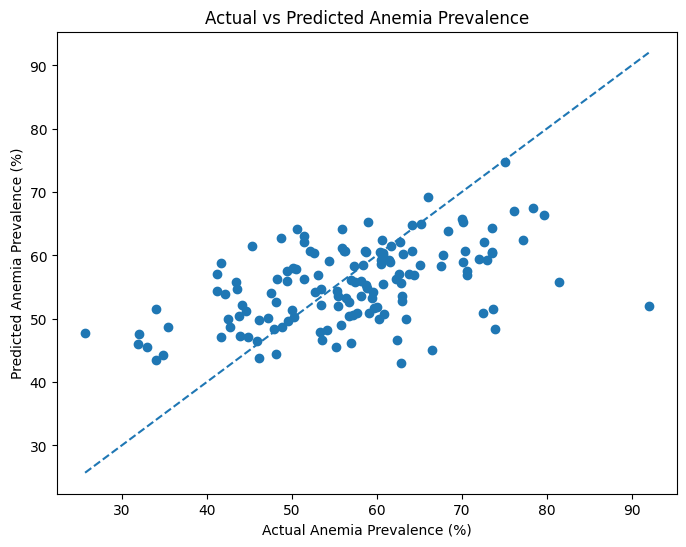

In [14]:
# Visualize actual vs predicted anemia prevalence

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Anemia Prevalence (%)")
plt.ylabel("Predicted Anemia Prevalence (%)")
plt.title("Actual vs Predicted Anemia Prevalence")

# Reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

In [15]:
# Save predictions and model coefficients

results.to_csv(
    "ML_Predictions.csv",
    index=False
)

coefficients.to_csv(
    "ML_Feature_Coefficients.csv",
    index=False
)

print("ML results saved successfully!")

ML results saved successfully!
